# Indian Data Analytics Job Market Intelligence Dashboard
Analysis of ~23,000 tech job postings scraped from Naukri.com (June 2025),
covering Data Analyst, Data Scientist, BI, ML, Data Engineer, and Python Developer roles.

**Goal:** Understand where Data Analyst demand concentrates in India — by city,
salary, experience level, work mode, and required skills — to identify the
most realistic entry points for breaking into the field.

## Phase 1
Load & First Inecpection

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
sns.set_style('whitegrid')
#using set_option to stops columns being truncated as we have 32 columns.
pd.set_option('display.max_columns', None)

df = pd.read_csv(r"C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Data\indian_tech_jobs_2026.csv")
df.shape

(23201, 32)

In [93]:
df.head(5)

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,salary_raw,salary_min_lpa,salary_max_lpa,salary_disclosed,skills_required,skills_count,job_description,posted_date_raw,work_mode,company_size_bucket,job_url,data_source,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,Not Disclosed,0.0,0.0,False,"Computer science, Data analysis, data science,...",8,"Bachelor s degree in Statistics, Mathematics, ...",3+ weeks ago,On-site,Large (1000+),https://www.naukri.com/job-listings-data-scien...,naukri.com,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,Not Disclosed,0.0,0.0,False,"Basic, Data management, Business analytics, An...",8,"Requirements Analysis: Knowledge of tools, met...",3+ weeks ago,On-site,Small/Startup (<100),https://www.naukri.com/job-listings-data-scien...,naukri.com,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Large (1000+),NaN,naukri.com,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,Not Disclosed,0.0,0.0,False,Not Available,0,Not Available,Not Available,On-site,Small/Startup (<100),NaN,naukri.com,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               23201 non-null  int64  
 1   job_title            23201 non-null  object 
 2   company_name         23201 non-null  object 
 3   company_rating       23201 non-null  float64
 4   location             23201 non-null  object 
 5   scraped_city         23201 non-null  object 
 6   role_category        23201 non-null  object 
 7   experience_raw       23201 non-null  object 
 8   experience_min_yrs   23201 non-null  float64
 9   experience_max_yrs   23201 non-null  float64
 10  salary_raw           23201 non-null  object 
 11  salary_min_lpa       23201 non-null  float64
 12  salary_max_lpa       23201 non-null  float64
 13  salary_disclosed     23201 non-null  bool   
 14  skills_required      23201 non-null  object 
 15  skills_count         23201 non-null 

In [95]:
df.isnull().sum()[df.isnull().sum() > 0]

job_url    53
dtype: int64

## Phase 2
Exposing disguised missing data

#### Data Quality Check
Salary and skills fields contain placeholder text ("Not Disclosed", "Not Available")
rather than true NaNs. This needs quantifying before any salary analysis, since
treating these as real zeros would massively understate pay.

In [96]:
print(df['salary_disclosed'].value_counts())
print(df['salary_disclosed'].value_counts(normalize = True) * 100)

salary_disclosed
False    20433
True      2768
Name: count, dtype: int64
salary_disclosed
False    88.06948
True     11.93052
Name: proportion, dtype: float64


In [97]:
df['skills_required'].eq('Not Available').sum()
df['job_description'].eq('Not Available').sum()

np.int64(404)

## Phase 3
Filtering to Data Analyst scope

In [98]:
df['role_category'].value_counts()

role_category
Data Scientist               6455
Data Analyst                 4729
Business Analyst             4505
Machine Learning Engineer    4004
Data Engineer                1922
Python Developer             1586
Name: count, dtype: int64

In [99]:
da = df[df['role_category'] == 'Data Analyst'].copy()
da.shape

(4729, 32)

## Phase 4
Cleaning

In [100]:
da['salary_disclosed'].sum()

np.int64(640)

In [101]:
da_salary = da[da['salary_disclosed'] == True].copy()
da_salary[['salary_min_lpa', 'salary_max_lpa', 'salary_midpoint_lpa']].describe()

,salary_min_lpa,salary_max_lpa,salary_midpoint_lpa
count,640.000000,640.000000,640.000000
mean,8.034688,13.214297,10.624547
std,6.251336,9.578990,7.826178
min,0.000000,0.050000,0.050000
25%,3.000000,5.300000,4.500000
50%,7.000000,12.000000,9.500000
75%,10.000000,18.000000,14.000000
max,60.000000,90.000000,75.000000


In [102]:
da['experience_tier'].value_counts()
da['work_mode'].value_counts()
da['primary_city'].value_counts().head(10)

primary_city
Noida        606
Bangalore    541
Ahmedabad    532
Kolkata      512
Pune         498
Chennai      477
Mumbai       464
Gurgaon      416
Remote       360
Delhi        164
Name: count, dtype: int64

In [103]:
da['skills_required'] = da['skills_required'].replace('Not Available', np.nan)
da_skills = da.dropna(subset=['skills_required']).copy()
da_skills.shape

(4598, 32)

## Phase 5
EDA: Answering business questions in code

#### Q1: Which cities have the most Data Analyst demand?

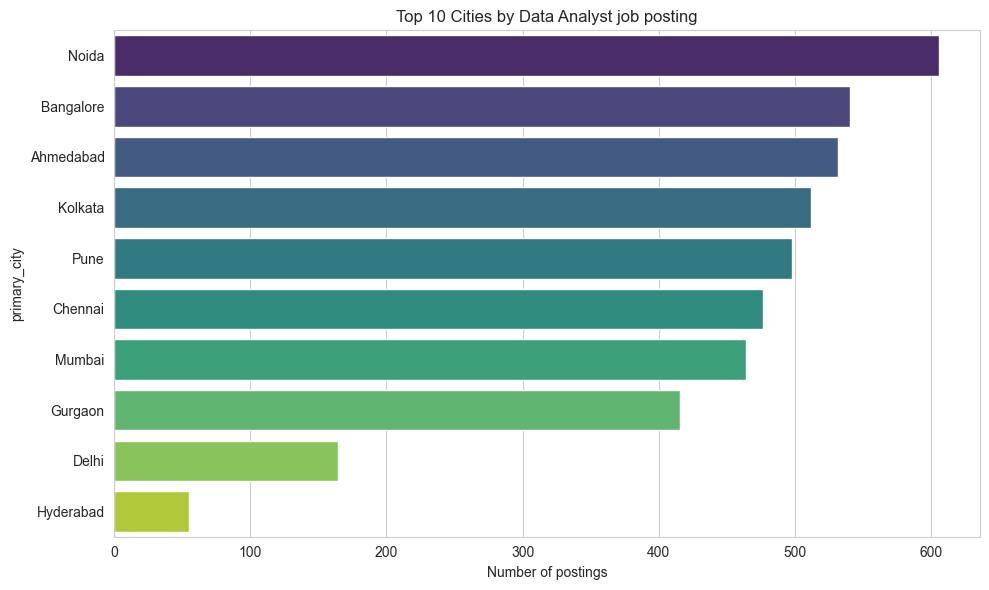

In [104]:
city_counts = da[da['primary_city'] != 'Remote']['primary_city'].value_counts().head(10)
plt.figure(figsize = (10,6))
sns.barplot(x=city_counts.values, y=city_counts.index, hue=city_counts.index, palette='viridis')
plt.title('Top 10 Cities by Data Analyst job posting')
plt.xlabel('Number of postings')
plt.tight_layout()
plt.savefig(r'C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Exports\01_top_cities', dpi=300)#
plt.show()

#### Q2: What's the experience distribution?(Is this field accessible to freshers?)

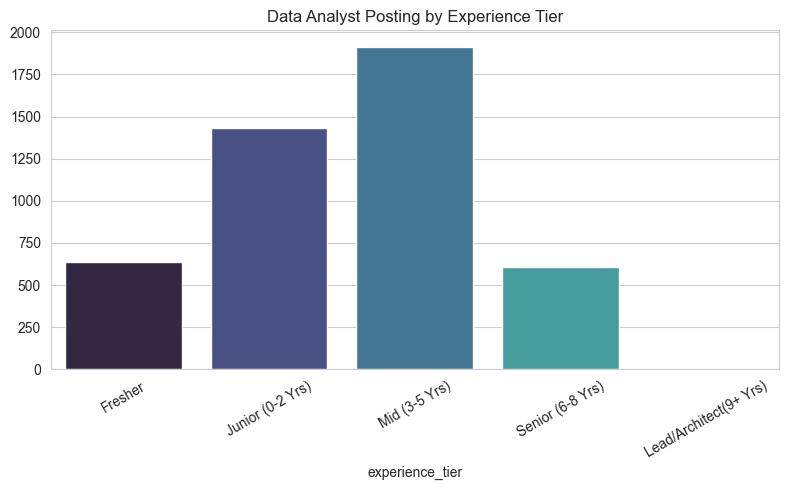

In [105]:
exp_order = ['Fresher', 'Junior (0-2 Yrs)', 'Mid (3-5 Yrs)', 'Senior (6-8 Yrs)', 'Lead/Architect(9+ Yrs)']
exp_counts = da['experience_tier'].value_counts().reindex(exp_order).fillna(0)
plt.figure(figsize=(8,5))
sns.barplot(x=exp_counts.index, y=exp_counts.values,hue=exp_counts.index, palette='mako')
plt.title('Data Analyst Posting by Experience Tier')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.savefig(r'C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Exports\02_experience_tiers.png', dpi=300)
plt.show()

#### Q3: Salary by experience tier(Where disclosed)

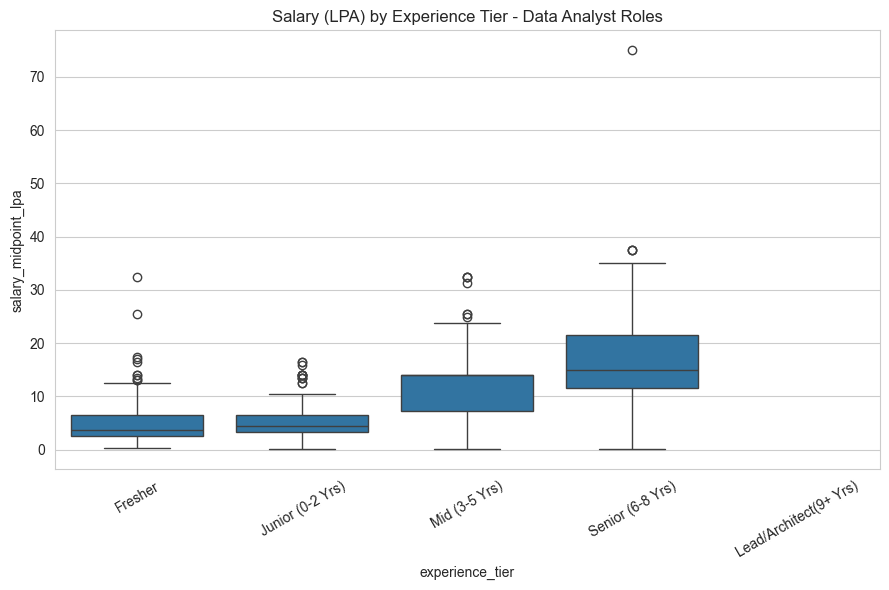

In [106]:
order = ['Fresher', 'Junior (0-2 Yrs)', 'Mid (3-5 Yrs)', 'Senior (6-8 Yrs)', 'Lead/Architect(9+ Yrs)']
plt.figure(figsize=(9,6))
sns.boxplot(data=da_salary, x='experience_tier', y='salary_midpoint_lpa', order=order)
plt.title('Salary (LPA) by Experience Tier - Data Analyst Roles')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.savefig(r'C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Exports\03_salary_by_experience.png', dpi=300)
plt.show()

#### Q4: Work mode breakdown

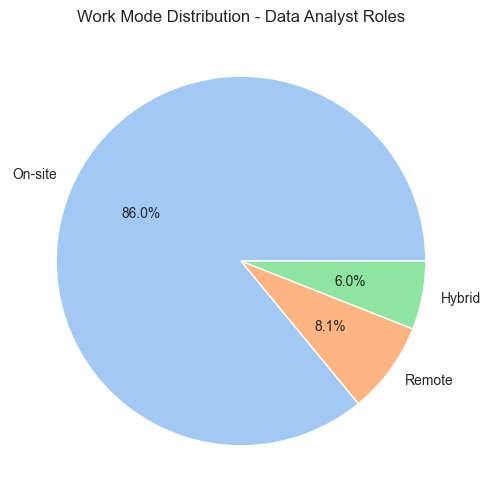

In [107]:
wm = da['work_mode'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(wm.values, labels = wm.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Work Mode Distribution - Data Analyst Roles')
plt.savefig(r'C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Exports\04_work_mode.png', dpi=300)
plt.show()

#### Q5: Most in demand skills

In [108]:
# Flatten the comma-separated skills column into one long list
all_skills_raw = da_skills['skills_required'].str.split(',').sum()
all_skills_clean = [s.strip().lower() for s in all_skills_raw]
print('Total tags:', len(all_skills_clean))

Total tags: 35815


In [109]:
# Define which tags are genuinely Data Analyst-relevant skills
# (the rest of the 3,000+ unique tags are cross-functional/unrelated noise
# from Naukri's shared tagging system across all job roles)
relevant_skills = [
    'sql', 'advanced sql', 'sql server', 'mysql', 'postgresql', 't-sql', 'pl / sql',
    'excel', 'advanced excel', 'ms excel', 'pivot table', 'vlookup', 'power pivot',
    'python', 'r', 'r programming',
    'power bi', 'powerbi', 'microsoft power bi', 'power bi desktop', 'dax',
    'tableau', 'tableau dashboards',
    'data visualization', 'data cleansing', 'data modeling', 'data wrangling',
    'business intelligence', 'data quality', 'business analysis', 'forecasting',
    'financial analysis', 'statistical analysis',
    'reporting', 'mis', 'mis reporting', 'dashboard', 'dashboards',
    'communication skills', 'problem solving', 'stakeholder management',
    'google sheets', 'google analytics', 'spss', 'sas', 'numpy', 'pandas',
    'machine learning', 'etl', 'data warehousing', 'big data',
    'looker', 'qlik', 'qlikview', 'alteryx', 'google data studio'
]

filtered_skills = [s for s in all_skills_clean if s in relevant_skills]
print(len(filtered_skills), 'relevant skill mentions found out of', len(all_skills_clean), 'total tags')

5159 relevant skill mentions found out of 35815 total tags


In [110]:
# Fix casing: title-case everything, then override acronyms
# that .title() would otherwise mangle (e.g. "Sql" -> should be "SQL")
acronym_overrides = {
    'sql': 'SQL', 'advanced sql': 'Advanced SQL', 'sql server': 'SQL Server',
    'mysql': 'MySQL', 'postgresql': 'PostgreSQL', 't-sql': 'T-SQL', 'pl / sql': 'PL/SQL',
    'power bi': 'Power BI', 'powerbi': 'Power BI', 'microsoft power bi': 'Power BI',
    'power bi desktop': 'Power BI Desktop', 'dax': 'DAX',
    'mis': 'MIS', 'mis reporting': 'MIS Reporting', 'etl': 'ETL', 'sas': 'SAS', 'spss': 'SPSS',
    'r': 'R', 'r programming': 'R'
}

filtered_skills_final = [acronym_overrides.get(s, s.title()) for s in filtered_skills]

In [111]:
# Count frequency and build top-15 DataFrame
skill_counts = Counter(filtered_skills_final)
top_skills = pd.DataFrame(skill_counts.most_common(15), columns=['skill', 'count'])
top_skills

,skill,count
0,Power BI,482
1,SQL,473
2,Business Analysis,471
3,Python,429
4,Excel,318
5,Machine Learning,250
6,Business Intelligence,229
7,Data Quality,201
8,Advanced Excel,171
9,Financial Analysis,149


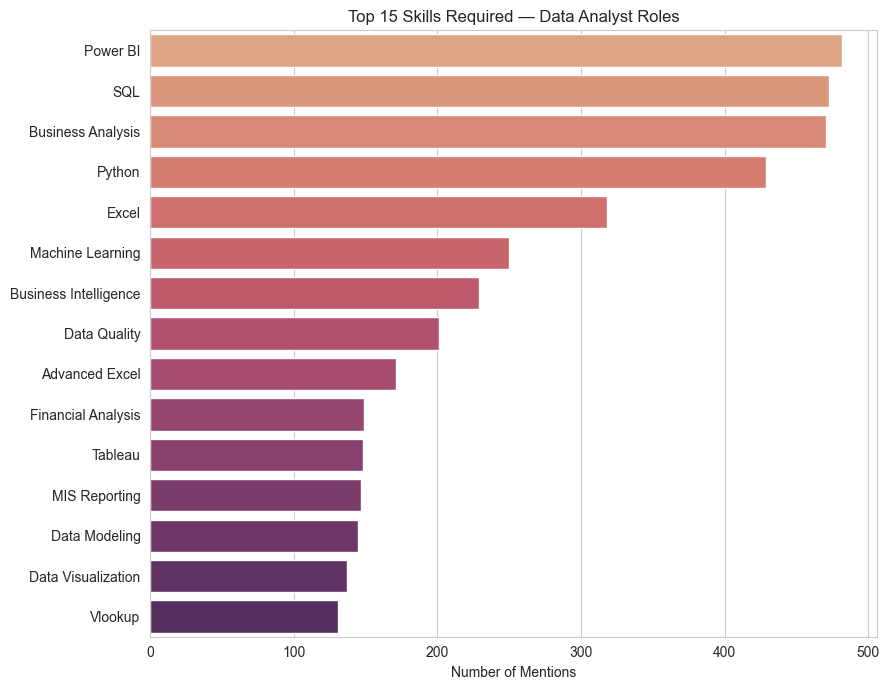

In [112]:
# Plot the data
plt.figure(figsize=(9,7))
sns.barplot(data=top_skills, x='count', y='skill', hue='skill', palette='flare', legend=False)
plt.title('Top 15 Skills Required — Data Analyst Roles')
plt.xlabel('Number of Mentions')
plt.ylabel('')
plt.tight_layout()
plt.savefig(r'C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Exports\05_top_skills.png', dpi=300)
plt.show()

#### Q6: Data Analyst vs other roles - salary comparison (uses full df, not da)

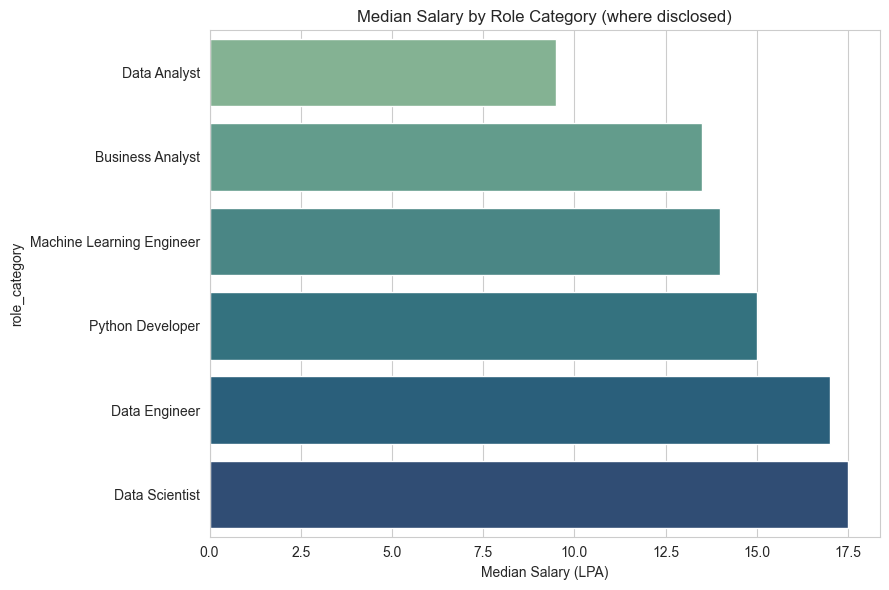

In [113]:
role_salary = df[df['salary_disclosed'] == True].groupby('role_category')['salary_midpoint_lpa'].median().sort_values()
plt.figure(figsize=(9,6))
sns.barplot(x=role_salary.values, y=role_salary.index, hue=role_salary.index, palette='crest', legend=False)
plt.title('Median Salary by Role Category (where disclosed)')
plt.xlabel('Median Salary (LPA)')
plt.tight_layout()
plt.savefig(r'C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Exports\06_role_salary_comparison.png', dpi=300)
plt.show()

## Phase 6
Exporting cleaned data for SQL & BI tools

In [114]:
da.to_csv(r'C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Cleaned data\data_analyst_cleaned.csv', index = False)
df.to_csv(r'C:\Users\jagan\Desktop\GitHub\Exploratory Data Analysis\Indian Job Market\Cleaned data\all_roles_cleaned.csv', index = False)